In [1]:
import numpy as np
import xarray as xr
import pandas as pd
import _utils

In [22]:
file_dir = "../mnt_processed_data/"

### CPC

In [2]:
pd.read_csv("../input_data/CPC_station_information/cpc_station_list_master.csv")

,wmo_id,stn_call,ghcnd_id,city,state,country,lat,lon,elev,source
0,1001.0,ENJA,JNM00001001,JAN_MAYEN(NOR-NAVY),NaN,NORWAY,70.9394,-8.6690,10.0,cpc+cadb
1,1002.0,NaN,NaN,VERLEGENHUKEN,NaN,NORWAY,80.0555,16.2500,8.0,cpc+cadb
2,1003.0,NaN,NaN,HORNSUND_RIVER,NaN,NORWAY,77.0002,15.5353,12.0,cpc+cadb
3,1004.0,NaN,NOE00134766,NY-ALESUND_I,NaN,NORWAY,78.9250,11.9300,42.0,mixed
4,1005.0,NaN,NOE00111363,ISFJORD_RADIO,NaN,NORWAY,78.0600,13.6300,9.0,cpc
...,...,...,...,...,...,...,...,...,...,...
20738,NaN,TJPS,NaN,MERCEDITA_AIRPORT,PR,PUERTO_RICO,18.0000,-66.5500,9.0,aviation+ncei
20739,NaN,TJVQ,NaN,VIEQUES_ISLAND_DZ,PR,UNITED_STATES,18.1500,-65.3833,NaN,ncei
20740,NaN,TRPG,NaN,JOHN_OSBORNE_APT,NaN,MONTSERRAT,16.7800,-62.2000,170.0,aviation+cadb
20741,NaN,TTCP,NaN,ARTHUR_NAPOLEON_RAYMOND_ROBINSON_INTERNATIONAL...,NaN,TRINIDAD_AND_TOBAGO,11.1500,-60.8330,12.0,ncei


In [3]:
df = pd.read_csv("../input_data/CPC_station_information/cpc_station_list_master.csv")  # columns: station_id, lat, lon, ...
df = df.dropna(subset=["lat", "lon"]).copy()

# Normalize longitudes to [-180, 180)
lon = df["lon"].values % 360
lat = df["lat"].values

# ---- Define 5° bins (edges) ----
lon_edges = np.arange(0, 360+5, 5)   # -180,-175,...,175,180  (length 73)
lat_edges = np.arange(-90,  90  + 5, 5)   #  -90, -85,..., 85, 90  (length 37)

# ---- 2D histogram of station counts per grid box ----
# H shape: (lat_bins-1, lon_bins-1) = (36, 72)
H, yedges, xedges = np.histogram2d(lat, lon, bins=[lat_edges, lon_edges])

# ---- Put into xarray with bin centers as coords ----
lon_centers = (xedges[:-1] + xedges[1:]) / 2.0  #  -177.5,...,177.5  (72)
lat_centers = (yedges[:-1] + yedges[1:]) / 2.0  #   -87.5,..., 87.5  (36)

cpc_count = xr.DataArray(
    H.astype(int),
    dims=("lat", "lon"),
    coords={"lat": lat_centers, "lon": lon_centers},
    name="gauge_count"
)

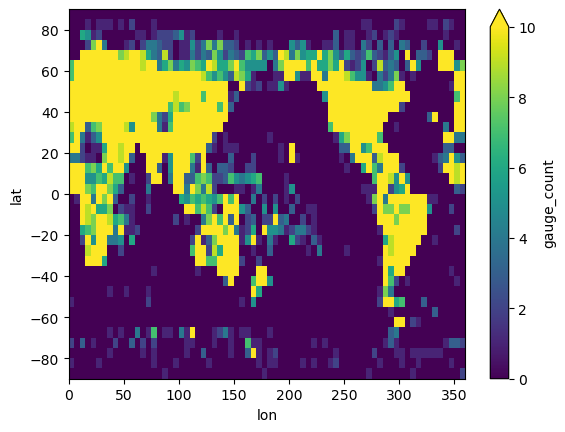

In [4]:
cpc_count.plot(vmin = 0, vmax = 10)

### GPCC: 
Note: numgauge variable is constant over time

In [5]:
gpcc_dat = xr.open_dataset("../input_data/GPCC_Monthly_Precip/v2022/25/full_data_monthly_v2022_2011_2020_25.nc")

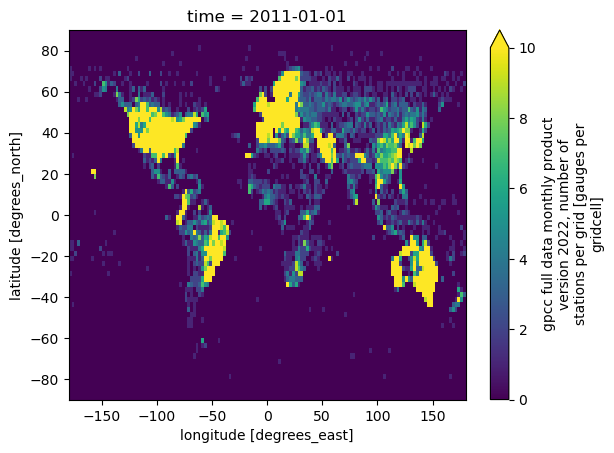

In [6]:
gpcc_dat.numgauge.isel(time = 0).plot(vmin = 0, vmax = 10)

In [7]:
gpcc_count = gpcc_dat.numgauge.isel(time = 0).coarsen(dim = {"lat": 2, "lon": 2}).sum()

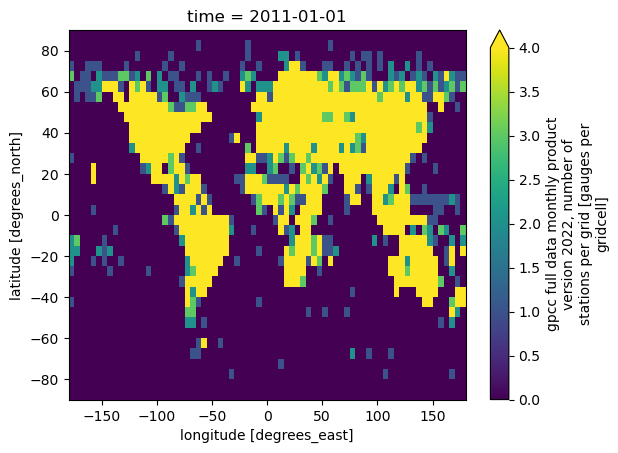

In [8]:
gpcc_count.plot(vmin = 0, vmax = 4)

In [9]:
## create one version of mask as long as each 5x5 cell has a gauge? 
## create one version where each 2.5 cell has gauge? 
## create one version where each 2.5 cell has multiple gauges (4??)

### REGEN

In [10]:
regen_all_mask = xr.open_dataset("../input_data/REGEN/AllStns/v1-2019/REGEN_AllStns_V1-2019_1950-2016_QualityMask.nc")

In [11]:
regen_mask = xr.open_dataset("../../DATA/REGEN/LongTermStns/v1-2019/REGEN_LongTermStns_V1-2019_1950-2016_QualityMask.nc")

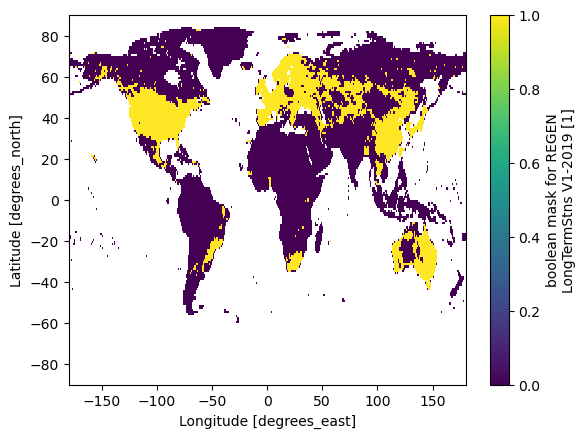

In [12]:
regen_mask.p.plot()

In [13]:
regen_mask_5deg = regen_mask.p.coarsen(dim = {"lat": 5, "lon": 5}).sum()

In [14]:
regen_mask_5deg["lon"] = regen_mask_5deg["lon"].values % 360
regen_mask_5deg = regen_mask_5deg.sortby("lon")

In [15]:
regen_mask_5deg

<xarray.DataArray 'p' (lat: 36, lon: 72)> Size: 21kB
array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 2., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])
Coordinates:
  * lat      (lat) float64 288B -87.5 -82.5 -77.5 -72.5 ... 72.5 77.5 82.5 87.5
  * lon      (lon) float64 576B 2.5 7.5 12.5 17.5 ... 342.5 347.5 352.5 357.5
Attributes:
    units:          1
    long_name:      boolean mask for REGEN LongTermStns V1-2019
    standard_name:  status_flag
    flag_values:    [-99999      0      1]
    flag_meanings:  ocean land_low_quality land_high_quality

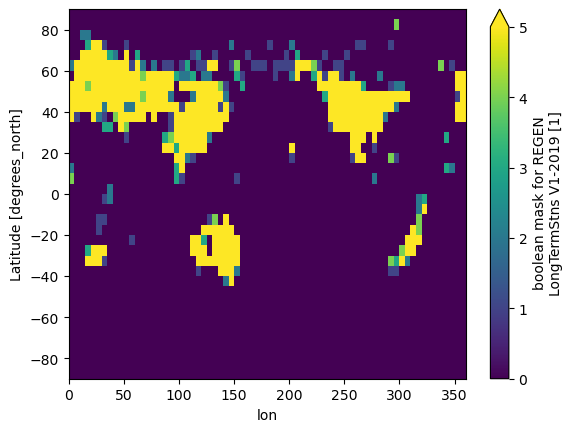

In [16]:
regen_mask_5deg.plot(vmin = 0, vmax = 5)

In [17]:
xr.where(regen_mask_5deg >= 2, 1, np.nan).sum()

<xarray.DataArray 'p' ()> Size: 8B
array(361.)

In [19]:
regen_mask_5deg.to_netcdf(file_dir+"regen_LongTerm_quality_mask.nc")

### CMIP Common Mask
all obs datasets, SPEAR, and MESACLIP have complete land area (relative to GPCC coverage)


In [26]:
cmip_day_trends = _utils.read_trends(file_dir, "cmip-sub", "rx1day", 1979, 2020)
cmip_mon_trends = _utils.read_trends(file_dir, "cmip-sub", "mon-p095", 1979, 2020)

In [27]:
cmip_day_mask = xr.where(xr.where(np.isnan(cmip_day_trends), 0, 1).sum(dim = "sim")==len(cmip_day_trends.sim),1,0)
print("number of daily CMIP grid cells in all models:", str((cmip_day_mask == 1).sum().values))

number of daily CMIP grid cells in all models: 693


In [28]:
cmip_mon_mask = xr.where(xr.where(np.isnan(cmip_mon_trends), 0, 1).sum(dim = "sim")==len(cmip_mon_trends.sim),1,0)
print("number of monthly CMIP grid cells in all models:", str((cmip_mon_mask == 1).sum().values))

number of monthly CMIP grid cells in all models: 693


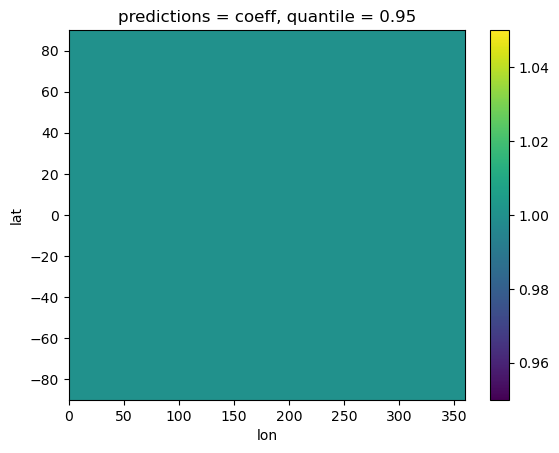

In [31]:
## check that masks are equivalent
(cmip_day_mask == cmip_mon_mask).plot()

In [32]:
cmip_day_mask.to_netcdf(file_dir+"common_land_mask.nc")

In [33]:
def model_mask(ds):
    return(xr.where(cmip_day_mask == 1, ds, np.nan))

combine station quality mask with common model mask:

In [34]:
regen_mask_5deg = model_mask(regen_mask_5deg)

In [35]:
xr.where(regen_mask_5deg >= 2, 1, np.nan).sum()

<xarray.DataArray ()> Size: 8B
array(308.)
Coordinates:
    predictions  <U9 36B 'coeff'

In [37]:
regen_mask_5deg.to_netcdf(file_dir+"combined_gauge_model_mask.nc")